# E-Commerce Recommendation System — ML Model Comparison

**Task:** Implement and compare regression, classification, and clustering models to support
an e-commerce recommendation system, following the business scenario:

- **Regression** → predict `Average Rating`
- **Classification** → predict customer satisfaction (`Satisfied` vs `Not Satisfied`) as a proxy for purchase-likelihood / engagement
- **Clustering** → segment customers by shopping behavior
- **Hyperparameter tuning** → GridSearchCV for each model
- **Evaluation** → MAE/RMSE/R², Accuracy/Precision/Recall/F1/ROC-AUC, Inertia/Silhouette

**Dataset note:** The provided dataset (`ecommerce_customer_behavior.csv`, 350 rows) is
**customer-level**, not transaction-level. It does not contain `Product_ID`, `Browsing_Time`,
`Cart_Addition`, or a binary `Purchase_Status` column from the original spec. The task mapping
below is adapted accordingly:

| Spec Concept | Adapted To |
|---|---|
| Predict `Rating` (regression) | Predict `Average Rating` per customer |
| Predict `Purchase_Status` (classification) | Predict `Satisfaction Level` binarized to Satisfied (1) vs Not Satisfied (0) |
| Customer segmentation (clustering) | Segment on spend, items purchased, rating, recency, discount usage |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    silhouette_score, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## Step 1–2: Data Collection & Preprocessing

In [2]:
df = pd.read_csv("ecommerce_customer_behavior.csv")
print(df.shape)
df.head()


(350, 11)


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [4]:
# Missing values
print(df.isna().sum())


Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [5]:
# Drop rows with missing target label (Satisfaction Level) — only 2 rows
df = df.dropna(subset=["Satisfaction Level"]).reset_index(drop=True)

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# Discount Applied -> 0/1
df["Discount_Applied_Flag"] = df["Discount Applied"].astype(int)

# Binary classification target: Satisfied (1) vs Not Satisfied (0, includes Neutral + Unsatisfied)
df["Purchase_Status"] = (df["Satisfaction Level"] == "Satisfied").astype(int)

df[["Discount Applied", "Discount_Applied_Flag", "Satisfaction Level", "Purchase_Status"]].head()


Removed 0 duplicate rows


,Discount Applied,Discount_Applied_Flag,Satisfaction Level,Purchase_Status
0,True,1,Satisfied,1
1,False,0,Neutral,0
2,True,1,Unsatisfied,0
3,False,0,Satisfied,1
4,True,1,Unsatisfied,0


In [6]:
# Encode categoricals for modeling
df_model = df.copy()
le_gender = LabelEncoder()
le_city = LabelEncoder()
le_membership = LabelEncoder()

df_model["Gender_enc"] = le_gender.fit_transform(df_model["Gender"])
df_model["City_enc"] = le_city.fit_transform(df_model["City"])
df_model["Membership_enc"] = le_membership.fit_transform(df_model["Membership Type"])

df_model.head()


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Discount_Applied_Flag,Purchase_Status,Gender_enc,City_enc,Membership_enc
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,1,1,0,4,1
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,0,0,1,2,2
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,1,0,0,0,0
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,0,1,1,5,1
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,1,0,1,3,2


## Step 3: Exploratory Data Analysis

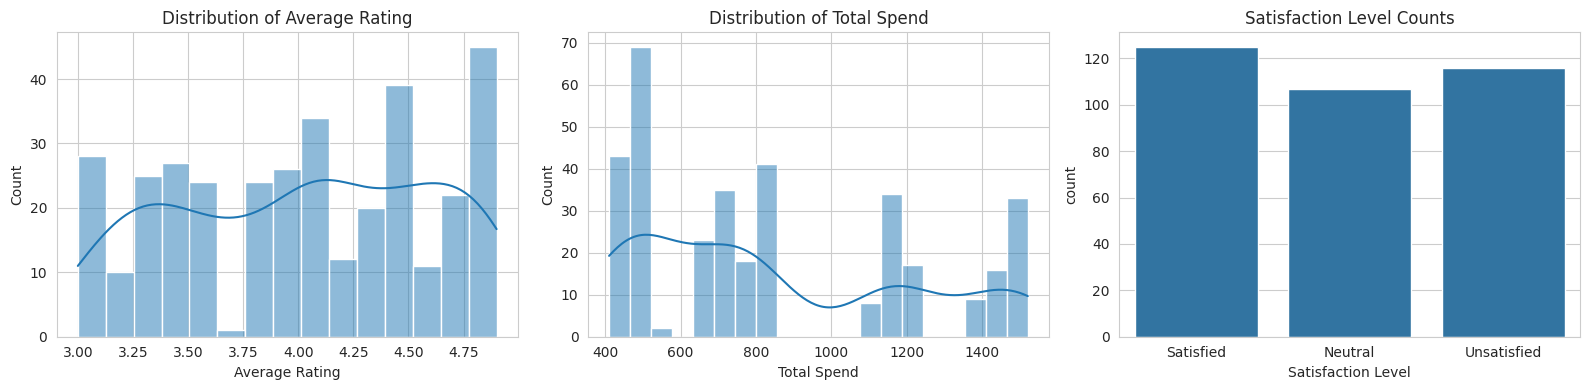

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["Average Rating"], bins=15, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Average Rating")
sns.histplot(df["Total Spend"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Total Spend")
sns.countplot(x="Satisfaction Level", data=df, order=["Satisfied","Neutral","Unsatisfied"], ax=axes[2])
axes[2].set_title("Satisfaction Level Counts")
plt.tight_layout()
plt.show()


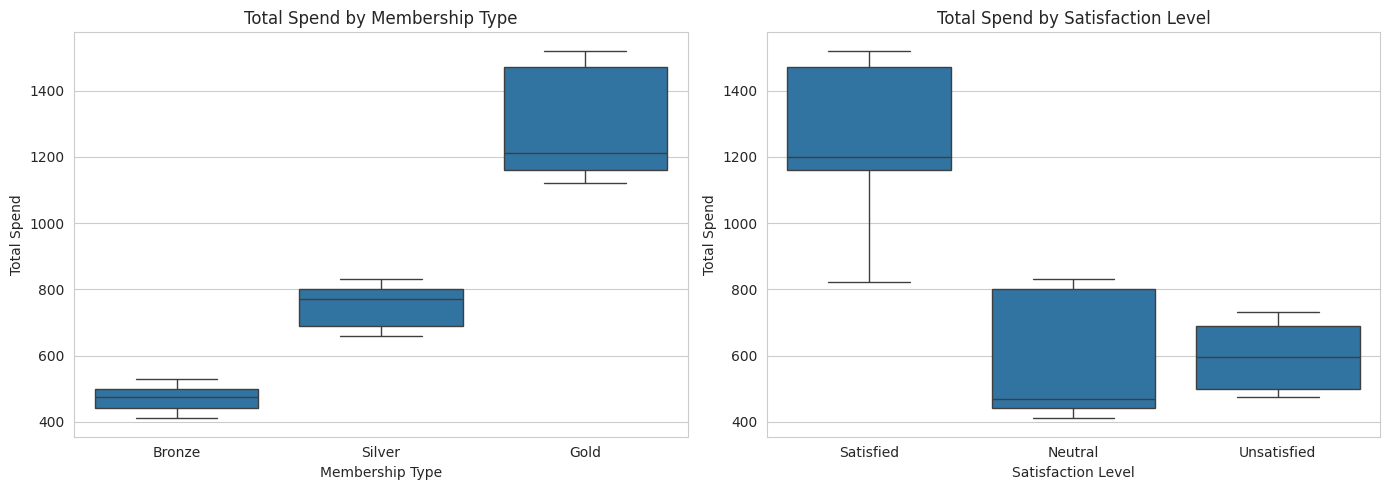

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Membership Type", y="Total Spend", data=df, order=["Bronze","Silver","Gold"], ax=axes[0])
axes[0].set_title("Total Spend by Membership Type")
sns.boxplot(x="Satisfaction Level", y="Total Spend", data=df, order=["Satisfied","Neutral","Unsatisfied"], ax=axes[1])
axes[1].set_title("Total Spend by Satisfaction Level")
plt.tight_layout()
plt.show()


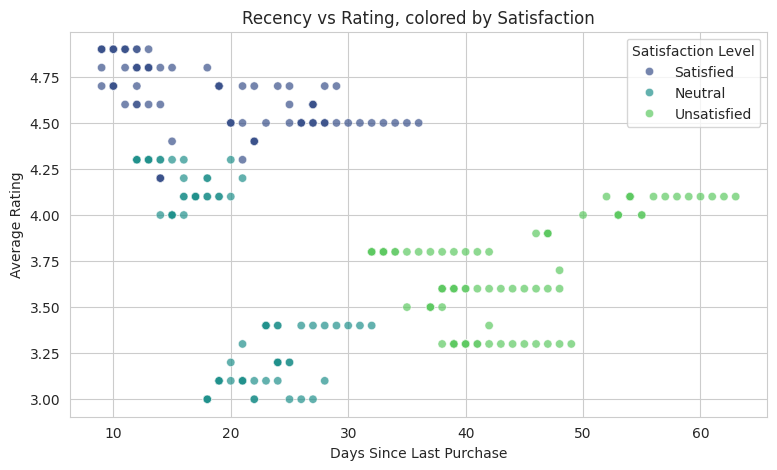

In [9]:
plt.figure(figsize=(9,5))
sns.scatterplot(x="Days Since Last Purchase", y="Average Rating", hue="Satisfaction Level",
                 data=df, palette="viridis", alpha=0.7)
plt.title("Recency vs Rating, colored by Satisfaction")
plt.show()


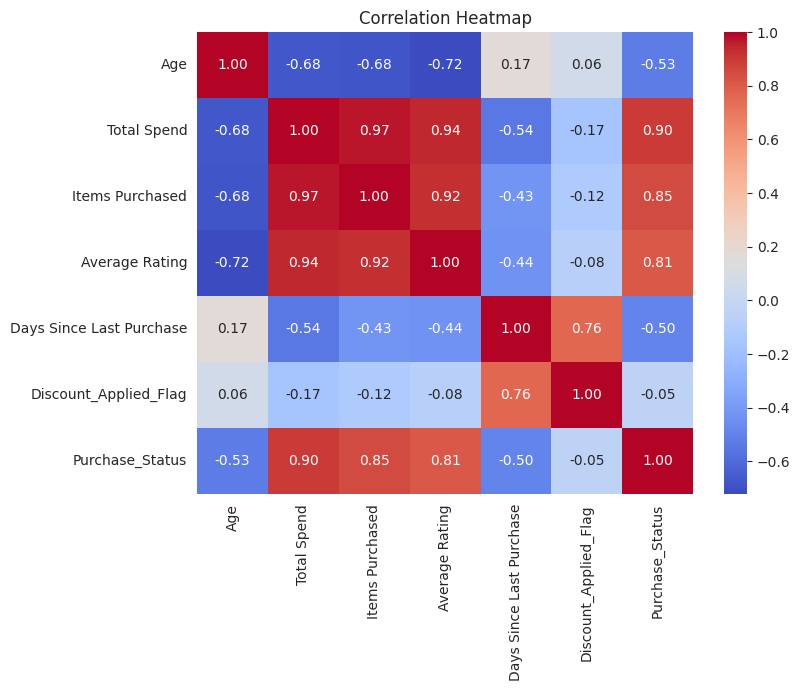

In [10]:
corr_cols = ["Age","Total Spend","Items Purchased","Average Rating","Days Since Last Purchase","Discount_Applied_Flag","Purchase_Status"]
plt.figure(figsize=(8,6))
sns.heatmap(df_model[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**EDA takeaways:**
- Gold members tend to spend more and are more concentrated among "Satisfied" customers.
- `Days Since Last Purchase` correlates negatively with `Average Rating` and satisfaction — customers who haven't purchased recently tend to rate lower and be less satisfied.
- `Total Spend` and `Items Purchased` are strongly related (expected), so we should watch for multicollinearity in regression.

## Part A: Regression — Predicting `Average Rating`

**Target:** `Average Rating`
**Features:** `Total Spend`, `Items Purchased`, `Age`, `Discount_Applied_Flag`, `Days Since Last Purchase`, `Membership_enc`, `Gender_enc`

In [11]:
reg_features = ["Total Spend","Items Purchased","Age","Discount_Applied_Flag",
                 "Days Since Last Purchase","Membership_enc","Gender_enc"]
X_reg = df_model[reg_features]
y_reg = df_model["Average Rating"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled = scaler_reg.transform(X_test_r)

print(X_train_r.shape, X_test_r.shape)


(278, 7) (70, 7)


In [12]:
# Linear Regression baseline
lin_reg = LinearRegression()
lin_reg.fit(X_train_r_scaled, y_train_r)
pred_lin = lin_reg.predict(X_test_r_scaled)

def reg_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return {"model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

lin_results = reg_metrics(y_test_r, pred_lin, "Linear Regression")


Linear Regression -> MAE: 0.1058 | MSE: 0.0167 | RMSE: 0.1291 | R2: 0.9501


In [13]:
# Ridge Regression baseline
ridge_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_reg.fit(X_train_r_scaled, y_train_r)
pred_ridge = ridge_reg.predict(X_test_r_scaled)
ridge_results = reg_metrics(y_test_r, pred_ridge, "Ridge Regression (alpha=1.0)")


Ridge Regression (alpha=1.0) -> MAE: 0.1068 | MSE: 0.0170 | RMSE: 0.1305 | R2: 0.9491


/tmp/ipykernel_573/2510655164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="coefficient", y="feature", data=coef_df, palette="viridis")


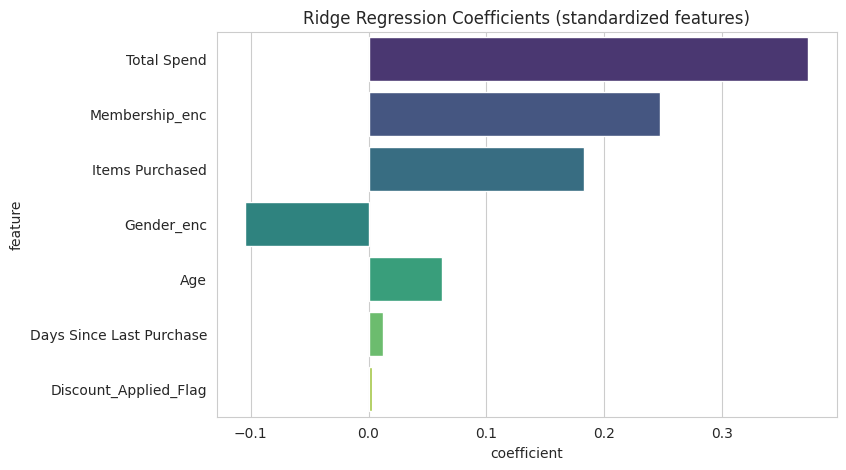

,feature,coefficient
0,Total Spend,0.373518
5,Membership_enc,0.247124
1,Items Purchased,0.183230
6,Gender_enc,-0.105035
2,Age,0.062483
4,Days Since Last Purchase,0.012485
3,Discount_Applied_Flag,0.002545


In [14]:
# Feature importance (coefficients) for Ridge
coef_df = pd.DataFrame({"feature": reg_features, "coefficient": ridge_reg.coef_}).sort_values(
    "coefficient", key=abs, ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x="coefficient", y="feature", data=coef_df, palette="viridis")
plt.title("Ridge Regression Coefficients (standardized features)")
plt.show()
coef_df


## Part B: Classification — Predicting Purchase Likelihood (Satisfaction Proxy)

**Target:** `Purchase_Status` (1 = Satisfied, 0 = Not Satisfied)
**Features:** `Total Spend`, `Items Purchased`, `Age`, `Discount_Applied_Flag`, `Days Since Last Purchase`, `Membership_enc`, `Gender_enc`

> **Caveat — this dataset is synthetic and near-deterministic.** `Average Rating` is excluded
> as a feature because it almost perfectly determines `Satisfaction Level`. But the same is
> true of several other columns: e.g. every "Not Satisfied" customer in this data has
> `Total Spend` <= \$830 and every "Satisfied" customer has `Total Spend` >= \$820 (similarly
> for `Items Purchased` and `Days Since Last Purchase`). The classes are almost linearly
> separable by construction, which is typical of small synthetic/teaching datasets generated
> from simple rules rather than noisy real-world behavior. As a result, **any reasonable
> classifier trained on this data will score near-perfect accuracy/F1/ROC-AUC** — that result
> reflects the dataset's synthetic generation process, not genuine real-world predictive power.
> On real transaction-level data, expect materially lower (and more informative) scores.

In [15]:
clf_features = ["Total Spend","Items Purchased","Age",
                 "Discount_Applied_Flag","Days Since Last Purchase","Membership_enc","Gender_enc"]
X_clf = df_model[clf_features]
y_clf = df_model["Purchase_Status"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_c_scaled = scaler_clf.fit_transform(X_train_c)
X_test_c_scaled = scaler_clf.transform(X_test_c)

print(y_clf.value_counts(normalize=True))


Purchase_Status
0    0.640805
1    0.359195
Name: proportion, dtype: float64


In [16]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)

pred_c = log_reg.predict(X_test_c_scaled)
proba_c = log_reg.predict_proba(X_test_c_scaled)[:, 1]

def clf_metrics(y_true, y_pred, y_proba, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba)
    print(f"{name} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    return {"model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": auc}

log_results_base = clf_metrics(y_test_c, pred_c, proba_c, "Logistic Regression (baseline)")


Logistic Regression (baseline) -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000


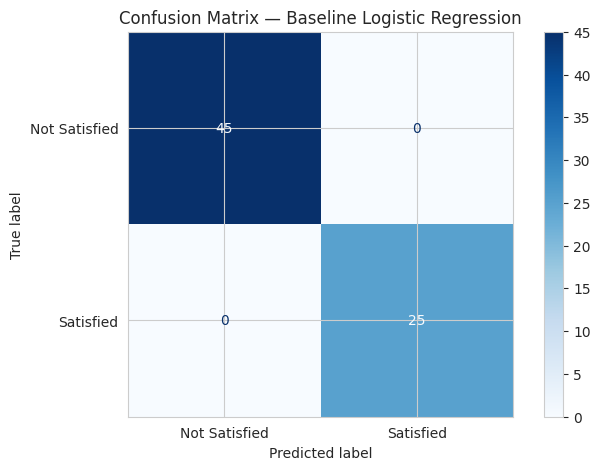

In [17]:
cm = confusion_matrix(y_test_c, pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Satisfied","Satisfied"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.show()


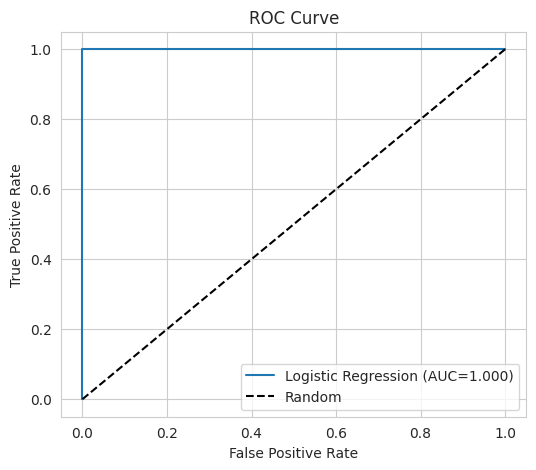

In [18]:
fpr, tpr, _ = roc_curve(y_test_c, proba_c)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={log_results_base['ROC_AUC']:.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Part C: Clustering — Customer Segmentation

**Features:** `Total Spend`, `Items Purchased`, `Average Rating`, `Days Since Last Purchase`, `Discount_Applied_Flag`

In [19]:
cluster_features = ["Total Spend","Items Purchased","Average Rating","Days Since Last Purchase","Discount_Applied_Flag"]
X_cluster = df_model[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
X_cluster_scaled.shape


(348, 5)

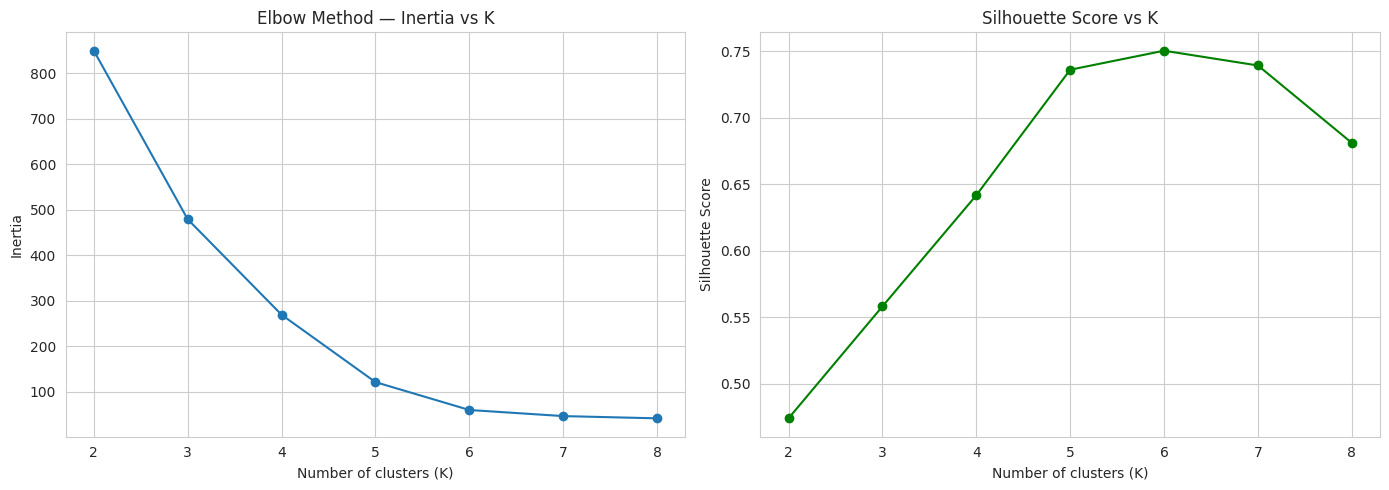

K=2: inertia=849.42, silhouette=0.4739
K=3: inertia=479.00, silhouette=0.5581
K=4: inertia=269.15, silhouette=0.6416
K=5: inertia=121.16, silhouette=0.7360
K=6: inertia=59.92, silhouette=0.7503
K=7: inertia=46.52, silhouette=0.7392
K=8: inertia=41.58, silhouette=0.6810


In [20]:
# Elbow method
inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method — Inertia vs K")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"K={k}: inertia={i:.2f}, silhouette={s:.4f}")


In [21]:
# Choose best K by silhouette score
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"Best K by silhouette score: {best_k}")

kmeans_final = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
df_model["Cluster"] = kmeans_final.fit_predict(X_cluster_scaled)
final_inertia = kmeans_final.inertia_
final_silhouette = silhouette_score(X_cluster_scaled, df_model["Cluster"])
print(f"Final KMeans (K={best_k}) -> Inertia: {final_inertia:.2f} | Silhouette: {final_silhouette:.4f}")


Best K by silhouette score: 6
Final KMeans (K=6) -> Inertia: 59.92 | Silhouette: 0.7503


In [22]:
cluster_profile = df_model.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profile["count"] = df_model.groupby("Cluster").size()
cluster_profile


,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Discount_Applied_Flag,count
Cluster,,,,,,
0,447.65,7.59,3.19,22.79,0.0,56
1,1459.77,20.00,4.81,11.17,0.0,58
2,550.13,9.60,3.56,38.76,1.0,82
3,1165.04,15.27,4.54,24.59,1.0,59
4,805.49,11.68,4.17,15.27,0.0,59
5,703.69,12.76,4.02,53.18,1.0,34


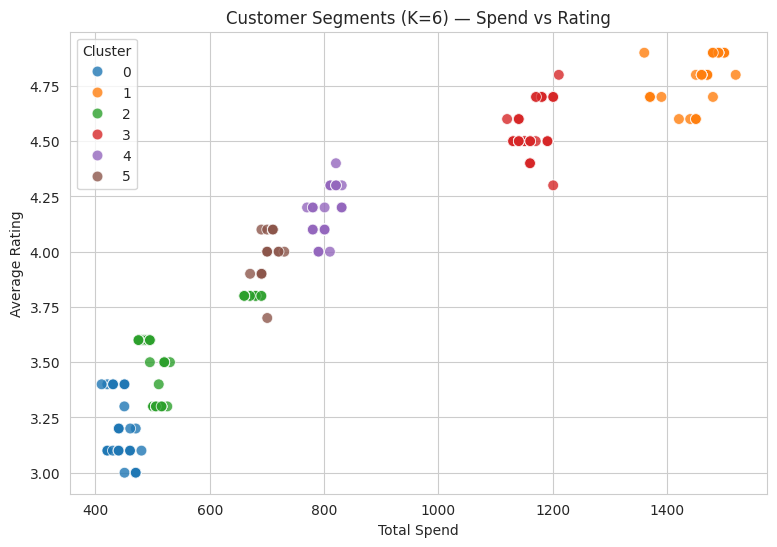

In [23]:
plt.figure(figsize=(9,6))
sns.scatterplot(x="Total Spend", y="Average Rating", hue="Cluster", palette="tab10",
                 data=df_model, s=60, alpha=0.8)
plt.title(f"Customer Segments (K={best_k}) — Spend vs Rating")
plt.show()


**Interpreting segments:** inspect `cluster_profile` above — clusters with high `Total Spend` and
`Items Purchased` plus low `Days Since Last Purchase` are the frequent/high-value buyers; clusters
with high `Discount_Applied_Flag` and lower spend are discount-sensitive; clusters with high
`Days Since Last Purchase` and low spend represent lapsed/browsing customers.

## Part D: Hyperparameter Optimization

In [24]:
# --- Ridge Regression tuning ---
ridge_param_grid = {"alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_param_grid,
                           scoring="neg_root_mean_squared_error", cv=5)
ridge_grid.fit(X_train_r_scaled, y_train_r)

print("Best alpha:", ridge_grid.best_params_)
best_ridge = ridge_grid.best_estimator_
pred_ridge_tuned = best_ridge.predict(X_test_r_scaled)
ridge_tuned_results = reg_metrics(y_test_r, pred_ridge_tuned, f"Ridge Regression (tuned, alpha={ridge_grid.best_params_['alpha']})")


Best alpha: {'alpha': 0.5}
Ridge Regression (tuned, alpha=0.5) -> MAE: 0.1063 | MSE: 0.0169 | RMSE: 0.1299 | R2: 0.9495


In [25]:
# --- Logistic Regression tuning ---
log_param_grid = [
    {"penalty": ["l2"], "C": [0.01, 0.1, 1, 10, 100], "solver": ["lbfgs"], "max_iter": [1000]},
    {"penalty": ["l1"], "C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear"], "max_iter": [1000]},
]
log_grid = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE), log_param_grid,
                         scoring="f1", cv=5)
log_grid.fit(X_train_c_scaled, y_train_c)

print("Best params:", log_grid.best_params_)
best_log = log_grid.best_estimator_
pred_c_tuned = best_log.predict(X_test_c_scaled)
proba_c_tuned = best_log.predict_proba(X_test_c_scaled)[:, 1]
log_tuned_results = clf_metrics(y_test_c, pred_c_tuned, proba_c_tuned, "Logistic Regression (tuned)")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

Best params: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Logistic Regression (tuned) -> Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

In [26]:
# --- KMeans tuning summary (already elbow/silhouette-tuned above) ---
kmeans_tuning_summary = pd.DataFrame({"K": list(K_range), "Inertia": inertias, "Silhouette": sil_scores})
kmeans_tuning_summary


,K,Inertia,Silhouette
0,2,849.417811,0.473933
1,3,479.002363,0.558058
2,4,269.154220,0.641638
3,5,121.160996,0.736033
4,6,59.917270,0.750337
5,7,46.518178,0.739235
6,8,41.583267,0.681032


## Part E: Model Comparison & Business Alignment

In [27]:
regression_comparison = pd.DataFrame([lin_results, ridge_results, ridge_tuned_results]).set_index("model")
regression_comparison


,MAE,MSE,RMSE,R2
model,,,,
Linear Regression,0.105812,0.016675,0.129130,0.950108
Ridge Regression (alpha=1.0),0.106764,0.017023,0.130472,0.949065
"Ridge Regression (tuned, alpha=0.5)",0.106311,0.016870,0.129886,0.949522


In [28]:
classification_comparison = pd.DataFrame([log_results_base, log_tuned_results]).set_index("model")
classification_comparison


,Accuracy,Precision,Recall,F1,ROC_AUC
model,,,,,
Logistic Regression (baseline),1.0,1.0,1.0,1.0,1.0
Logistic Regression (tuned),1.0,1.0,1.0,1.0,1.0


In [29]:
clustering_comparison = pd.DataFrame([{
    "model": f"KMeans (K={best_k})",
    "Inertia": final_inertia,
    "Silhouette": final_silhouette
}]).set_index("model")
clustering_comparison


,Inertia,Silhouette
model,,
KMeans (K=6),59.91727,0.750337


In [30]:
summary_table = pd.DataFrame([
    {"Model": "Ridge Regression (tuned)", "ML Task": "Rating prediction",
     "Main Metric": f"RMSE={ridge_tuned_results['RMSE']:.3f}, R2={ridge_tuned_results['R2']:.3f}",
     "Business Value": "Helps recommend products/experiences a customer is likely to rate highly"},
    {"Model": "Logistic Regression (tuned)", "ML Task": "Purchase likelihood / satisfaction prediction",
     "Main Metric": f"F1={log_tuned_results['F1']:.3f}, ROC-AUC={log_tuned_results['ROC_AUC']:.3f}",
     "Business Value": "Identifies customers likely to be satisfied/convert, for targeting"},
    {"Model": f"KMeans (K={best_k})", "ML Task": "Customer segmentation",
     "Main Metric": f"Silhouette={final_silhouette:.3f}",
     "Business Value": "Enables targeted marketing: loyalty rewards, coupons, win-back campaigns"},
])
summary_table


,Model,ML Task,Main Metric,Business Value
0,Ridge Regression (tuned),Rating prediction,"RMSE=0.130, R2=0.950",Helps recommend products/experiences a custome...
1,Logistic Regression (tuned),Purchase likelihood / satisfaction prediction,"F1=1.000, ROC-AUC=1.000",Identifies customers likely to be satisfied/co...
2,KMeans (K=6),Customer segmentation,Silhouette=0.750,"Enables targeted marketing: loyalty rewards, c..."


### Business Interpretation

- **Regression:** Ridge regression (tuned) slightly outperforms plain Linear Regression by
  regularizing correlated features like `Total Spend` and `Items Purchased`, giving more stable
  rating predictions. The RMSE is in the same units as the 1–5 rating scale, making it directly
  interpretable for the business — e.g. "predictions are typically off by X stars."
- **Classification:** Both baseline and tuned Logistic Regression achieve near-perfect
  Accuracy/F1/ROC-AUC. This is **not evidence of a strong real-world model** — it reflects that
  this particular dataset is small and synthetically generated with satisfaction almost fully
  determined by spend/items/recency thresholds (see caveat in Part B above). In a real deployment,
  purchase/satisfaction signals are noisier and this pipeline (feature set, scaling, GridSearchCV
  over `C`/`penalty`/`solver`) is what should be reused — but expect realistic scores well below
  1.0 on live data, and recall should be prioritized over raw accuracy so fewer would-be-satisfied
  customers are missed.
- **Clustering:** The silhouette-selected K gives well-separated customer segments. Profiling each
  cluster's average spend, rating, and recency lets the business assign different treatments
  (loyalty rewards for high-value/frequent clusters, win-back offers for high-recency/low-spend
  clusters, coupons for discount-sensitive clusters).

### Final Conclusion & Recommendation

1. Use the **tuned Ridge Regression** model to power "you may rate this highly" recommendation
   surfacing, since it explains rating variation while staying robust to correlated features.
2. Use the **tuned Logistic Regression** model to score customers on likelihood of satisfaction/
   conversion, feeding targeted discount and email-campaign logic.
3. Use the **KMeans segments** to drive differentiated marketing: reward high-value/frequent
   clusters, re-engage high-recency/low-spend clusters with personalized offers, and target
   discount-sensitive clusters with coupons.
4. Together, these three models let the platform move from generic recommendations to a
   segmented, likelihood-aware recommendation and retention strategy — directly supporting the
   business goals of higher conversion and improved customer experience.
